# EDA on Motor Function

- MDS-UPDRS_Part_III_14Dec2025.csv
- MDS_UPDRS_Part_II__Patient_Questionnaire_14Dec2025.csv
- MDS-UPDRS_Part_I_14Dec2025.csv
- MDS-UPDRS_Part_I_Patient_Questionnaire_14Dec2025.csv
- MDS-UPDRS_Part_IV__Motor_Complications_14Dec2025.csv
- Modified_Schwab___England_Activities_of_Daily_Living_14Dec2025.csv
- Neuro_QoL__Lower_Extremity_Function__Mobility__-_Short_Form_14Dec2025.csv
- Neuro_QoL__Upper_Extremity_Function_-_Short_Form_14Dec2025.csv
- Participant_Motor_Function_Questionnaire_14Dec2025.csv

In [9]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

# Allow pandas to show all columns
pd.set_option('display.max_columns', None)

In [4]:
# Load master_df
master_df = pd.read_csv('../../Experiment/preprocessing/master_df.csv')
print('master_df:', master_df.shape)

# Load all CSV data from motor function modality
motor_part_3_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/MDS-UPDRS_Part_III_14Dec2025.csv')
motor_part_2_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/MDS_UPDRS_Part_II__Patient_Questionnaire_14Dec2025.csv')
motor_part_1_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/MDS-UPDRS_Part_I_14Dec2025.csv')
motor_part_1_patient_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/MDS-UPDRS_Part_I_Patient_Questionnaire_14Dec2025.csv')
motor_part_4_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/MDS-UPDRS_Part_IV__Motor_Complications_14Dec2025.csv')
schwab_and_eng_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/Modified_Schwab___England_Activities_of_Daily_Living_14Dec2025.csv')
nuero_qol_lower_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/Neuro_QoL__Lower_Extremity_Function__Mobility__-_Short_Form_14Dec2025.csv')
nuero_qol_upper_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/Neuro_QoL__Upper_Extremity_Function_-_Short_Form_14Dec2025.csv')
participant_motor_func_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/Participant_Motor_Function_Questionnaire_14Dec2025.csv')

print('motor_part_3_df:', motor_part_3_df.shape)
print('motor_part_2_df:', motor_part_2_df.shape)
print('motor_part_1_df:', motor_part_1_df.shape)
print('motor_part_1_patient_df:', motor_part_1_patient_df.shape)
print('motor_part_4_df:', motor_part_4_df.shape)
print('schwab_and_eng_df:', schwab_and_eng_df.shape)
print('nuero_qol_lower_df:', nuero_qol_lower_df.shape)
print('nuero_qol_upper_df:', nuero_qol_upper_df.shape)
print('participant_motor_func_df:', participant_motor_func_df.shape)

master_df: (4369, 5)
motor_part_3_df: (35937, 65)
motor_part_2_df: (33035, 22)
motor_part_1_df: (30608, 15)
motor_part_1_patient_df: (33034, 16)
motor_part_4_df: (10358, 23)
schwab_and_eng_df: (29368, 8)
nuero_qol_lower_df: (11362, 15)
nuero_qol_upper_df: (11358, 15)
participant_motor_func_df: (10962, 19)


/var/folders/62/zjqy8smd44n_h59ql8q_nhy80000gn/T/ipykernel_6416/3720230829.py:6: DtypeWarning: Columns (16,21) have mixed types. Specify dtype option on import or set low_memory=False.
  motor_part_3_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/MDS-UPDRS_Part_III_14Dec2025.csv')


In [5]:
motor_part_3_df.columns.tolist()

['REC_ID',
 'PATNO',
 'EVENT_ID',
 'PAG_NAME',
 'INFODT',
 'PDTRTMNT',
 'PDSTATE',
 'HRPOSTMED',
 'HRDBSON',
 'HRDBSOFF',
 'PDMEDYN',
 'DBSYN',
 'ONOFFORDER',
 'OFFEXAM',
 'OFFNORSN',
 'DBSOFFYN',
 'DBSOFFTM',
 'ONEXAM',
 'ONNORSN',
 'HIFUYN',
 'DBSONYN',
 'DBSONTM',
 'PDMEDDT',
 'PDMEDTM',
 'EXAMDT',
 'EXAMTM',
 'NP3SPCH',
 'NP3FACXP',
 'NP3RIGN',
 'NP3RIGRU',
 'NP3RIGLU',
 'NP3RIGRL',
 'NP3RIGLL',
 'NP3FTAPR',
 'NP3FTAPL',
 'NP3HMOVR',
 'NP3HMOVL',
 'NP3PRSPR',
 'NP3PRSPL',
 'NP3TTAPR',
 'NP3TTAPL',
 'NP3LGAGR',
 'NP3LGAGL',
 'NP3RISNG',
 'NP3GAIT',
 'NP3FRZGT',
 'NP3PSTBL',
 'NP3POSTR',
 'NP3BRADY',
 'NP3PTRMR',
 'NP3PTRML',
 'NP3KTRMR',
 'NP3KTRML',
 'NP3RTARU',
 'NP3RTALU',
 'NP3RTARL',
 'NP3RTALL',
 'NP3RTALJ',
 'NP3RTCON',
 'NP3TOT',
 'DYSKPRES',
 'DYSKIRAT',
 'NHY',
 'ORIG_ENTRY',
 'LAST_UPDATE']

In [6]:
# motor_part_3_df['EVENT_ID'].unique()
motor_part_3_df.head(5)

,REC_ID,PATNO,EVENT_ID,PAG_NAME,INFODT,PDTRTMNT,PDSTATE,HRPOSTMED,HRDBSON,HRDBSOFF,PDMEDYN,DBSYN,ONOFFORDER,OFFEXAM,OFFNORSN,DBSOFFYN,DBSOFFTM,ONEXAM,ONNORSN,HIFUYN,DBSONYN,DBSONTM,PDMEDDT,PDMEDTM,EXAMDT,EXAMTM,NP3SPCH,NP3FACXP,NP3RIGN,NP3RIGRU,NP3RIGLU,NP3RIGRL,NP3RIGLL,NP3FTAPR,NP3FTAPL,NP3HMOVR,NP3HMOVL,NP3PRSPR,NP3PRSPL,NP3TTAPR,NP3TTAPL,NP3LGAGR,NP3LGAGL,NP3RISNG,NP3GAIT,NP3FRZGT,NP3PSTBL,NP3POSTR,NP3BRADY,NP3PTRMR,NP3PTRML,NP3KTRMR,NP3KTRML,NP3RTARU,NP3RTALU,NP3RTARL,NP3RTALL,NP3RTALJ,NP3RTCON,NP3TOT,DYSKPRES,DYSKIRAT,NHY,ORIG_ENTRY,LAST_UPDATE
0,272451901,3000,BL,NUPDRS3,02/2011,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02/2011,13:17:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,NaN,0.0,02/2011,2020-06-25 16:02:19
1,338703101,3000,V04,NUPDRS3,03/2012,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03/2012,13:47:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,NaN,0.0,03/2012,2020-06-25 16:02:22
2,385009801,3000,V06,NUPDRS3,02/2013,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02/2013,12:22:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,NaN,0.0,02/2013,2020-06-25 16:02:22
3,437131401,3000,V08,NUPDRS3,03/2014,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03/2014,13:22:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,NaN,0.0,05/2014,2020-06-25 16:02:22
4,512469901,3000,V10,NUPDRS3,03/2015,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03/2015,11:43:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,19.0,0.0,NaN,0.0,03/2015,2020-06-25 16:02:23


Data shape after cleaning: (29261, 36)
Correlation with NP3TOT:
NP3TOT                1.000000
Score_Bradykinesia    0.933169
Score_Rigidity        0.829451
Score_Bulbar          0.769222
Score_PIGD            0.700249
Score_Tremor          0.628196
Name: NP3TOT, dtype: float64

Top 10 Influential Features for PD Stage (NHY):
     Feature  Importance
17  NP3BRADY    0.112042
1   NP3FACXP    0.066915
7   NP3FTAPR    0.060371
4   NP3RIGLU    0.055587
27  NP3RTCON    0.053973
3   NP3RIGRU    0.053195
8   NP3FTAPL    0.047704
12  NP3PRSPL    0.047364
31  NP3PSTBL    0.047129
13  NP3TTAPR    0.041481


/var/folders/62/zjqy8smd44n_h59ql8q_nhy80000gn/T/ipykernel_6416/2863477986.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature', ax=axes[1], palette='viridis')


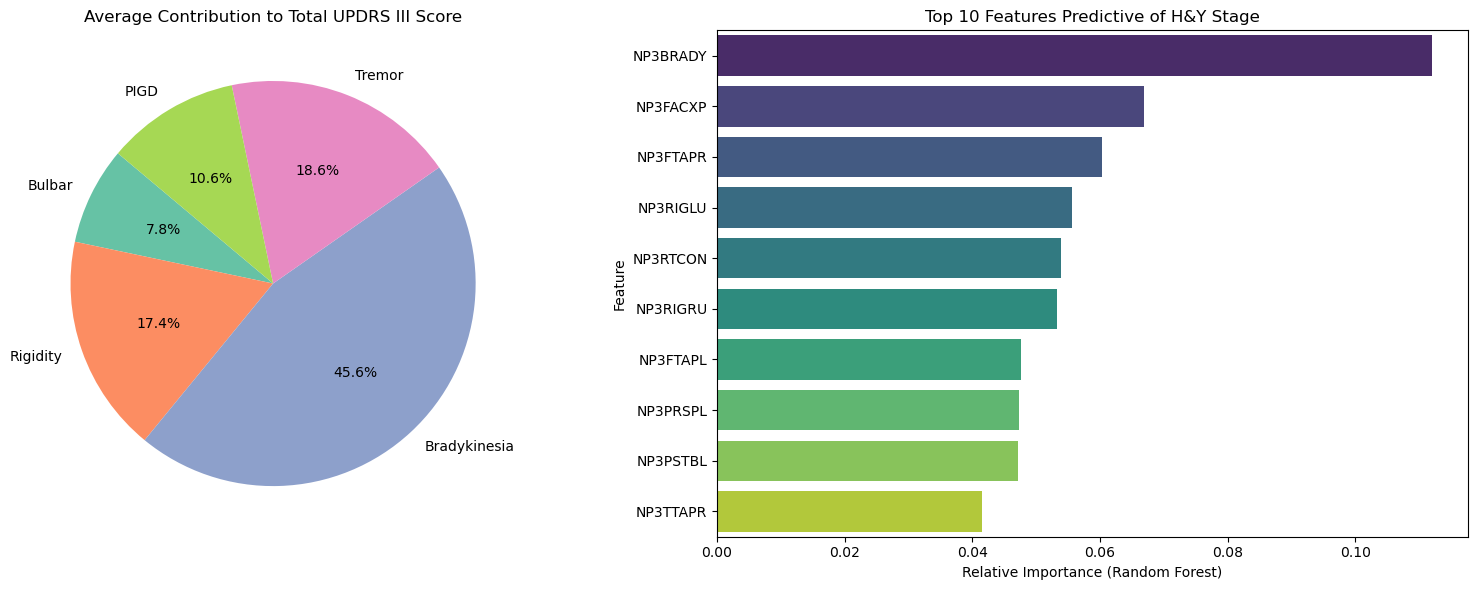

In [ ]:
# 1. Load Data
df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/MDS-UPDRS_Part_III_14Dec2025.csv', low_memory=False)

# 2. Define Subcategories
subcats = {
    'Bulbar': ['NP3SPCH', 'NP3FACXP'],
    'Rigidity': ['NP3RIGN', 'NP3RIGRU', 'NP3RIGLU', 'NP3RIGRL', 'NP3RIGLL'],
    'Bradykinesia': ['NP3FTAPR', 'NP3FTAPL', 'NP3HMOVR', 'NP3HMOVL', 
                     'NP3PRSPR', 'NP3PRSPL', 'NP3TTAPR', 'NP3TTAPL', 
                     'NP3LGAGR', 'NP3LGAGL', 'NP3BRADY'],
    'Tremor': ['NP3PTRMR', 'NP3PTRML', 'NP3KTRMR', 'NP3KTRML', 
               'NP3RTARU', 'NP3RTALU', 'NP3RTARL', 'NP3RTALL', 
               'NP3RTALJ', 'NP3RTCON'],
    'PIGD': ['NP3RISNG', 'NP3GAIT', 'NP3FRZGT', 'NP3PSTBL', 'NP3POSTR']
}

all_feature_cols = [col for cat in subcats.values() for col in cat]

# 3. Robust Preprocessing
# Keep only relevant columns to avoid dtype issues with irrelevant ones
work_df = df[['PATNO', 'NHY', 'NP3TOT'] + all_feature_cols].copy()

# Coerce to numeric
for col in work_df.columns:
    work_df[col] = pd.to_numeric(work_df[col], errors='coerce')

# Drop rows where Targets are missing
work_df = work_df.dropna(subset=['NP3TOT', 'NHY'])

# Fill missing feature values with 0 (Assuming missing sub-score ~ 0 or minor issue, or just to save data)
# Better: Use median
imputer = SimpleImputer(strategy='median')
work_df[all_feature_cols] = imputer.fit_transform(work_df[all_feature_cols])

print(f"Data shape after cleaning: {work_df.shape}")

# 4. Calculate Sub-Scores
for name, cols in subcats.items():
    work_df[f'Score_{name}'] = work_df[cols].sum(axis=1)

sub_score_cols = [f'Score_{name}' for name in subcats.keys()]

# 5. Correlation Analysis
corr_matrix = work_df[sub_score_cols + ['NP3TOT']].corr()
print("Correlation with NP3TOT:")
print(corr_matrix['NP3TOT'].sort_values(ascending=False))

# 6. Feature Importance (Predicting Stage)
X = work_df[all_feature_cols]
y = work_df['NHY'].astype(int).astype(str) # Convert to string classes '0', '1', '2'...

# Filter out rare classes if any (like Stage 5 might be rare) to avoid errors? RF handles it fine usually.
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

feature_importance = pd.DataFrame({
    'Feature': all_feature_cols,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Influential Features for PD Stage (NHY):")
print(feature_importance.head(10))

# 7. Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Contribution
avg_scores = work_df[sub_score_cols].mean()
axes[0].pie(avg_scores, labels=[c.replace('Score_', '') for c in avg_scores.index], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set2'))
axes[0].set_title('Average Contribution to Total UPDRS III Score')

# Plot B: Feature Importance
sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature', ax=axes[1], palette='viridis')
axes[1].set_title('Top 10 Features Predictive of H&Y Stage')
axes[1].set_xlabel('Relative Importance (Random Forest)')

plt.tight_layout()
# plt.savefig('updrs_influence_analysis.png')